# 1. Import all packages

In [ ]:
import numpy as np; from gprMax.utilities import detect_check_gpus; 
from gprMax.gprMax import api; 
import h5py; 
import matplotlib.pyplot as plt; 
import math
detect_check_gpus([0]);
import os; 
import torch
import time; 
from IPython.display import clear_output; 
os.getcwd(); 
from GPUtil import showUtilization as gpu_usage
from numba import cuda;
import gc; 
import pycuda.driver; 
import random; 
import pandas as pd;
from scipy.signal import hilbert
from bayes_opt import BayesianOptimization; 
import plotly.graph_objects as go; 
import pickle

In [2]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

In [4]:
# Function to clean GPU cache after gprMax and MCMC simulations
def free_gpu_cache():
    gc.collect()
    torch.cuda.empty_cache()
    try:
        n_devices = len(cuda.gpus)
    except Exception:
        n_devices = 0

    for dev_id in range(n_devices):
        try:
            cuda.select_device(dev_id)
            cuda.close()
            cuda.select_device(dev_id)
        except Exception:
            pass

    gpu_usage()
    gc.collect()
    torch.cuda.empty_cache()

free_gpu_cache()

| ID | GPU | MEM |
------------------
|  0 | 14% | 15% |


# 2. Load Raw experimental data

# 3. Creating the 'real' data

In [5]:
import os
import h5py
import subprocess
import sys

# --- One-time Setup for GPU Environment ---
# Try to find vcvars64.bat for environment setup
vcvars_candidates = [
    os.environ.get('VCVARS64_BAT', '').strip(),
    r'C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Progra~2\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Program Files\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Program Files (x86)\Microsoft Visual Studio\2019\BuildTools\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Program Files (x86)\Microsoft Visual Studio\2019\Community\VC\Auxiliary\Build\vcvars64.bat',
    r'C:\Program Files\Microsoft Visual Studio\2022\Community\VC\Auxiliary\Build\vcvars64.bat'
]

vcvars_bat = None
for candidate in vcvars_candidates:
    if candidate and os.path.exists(candidate):
        vcvars_bat = candidate
        break

current_python = sys.executable
print(f"Using Python: {current_python}")
if vcvars_bat:
    print(f"Found vcvars64.bat at: {vcvars_bat}")
else:
    print("Warning: vcvars64.bat not found. GPU simulation might fail.")

#Simulation
tw=1e-08;# Time window for FDTD simulation (time till which GPR receives signal)

def model_1L(c1):
    gpr_Y = 0.4
    fracture_Y = 0.0918
    
    # Generate unique filenames based on the Process ID
    pid = os.getpid()
    unique_input = f"Simulation_{pid}.in"
    unique_output = f"Simulation_{pid}.out"

    # Write to unique input file
    with open(unique_input, "w") as f:
        f.write("#title: Subwavelength Fracture")
        f.write("\n#domain: 1.0 0.5 0.0002")
        f.write("\n#dx_dy_dz: 0.0002 0.0002 0.0002")  
        f.write("\n#time_window: {}".format(tw))
        
        f.write("\n#material: 6.0 0.01 1 0 ice")
        f.write("\n#material: 1 0 1 0 air")
        f.write("\n#material: 80 {} 1 0 fracture".format(c1))

        f.write("\n#waveform: ricker 1 {} my_ricker".format(1.5e9))
        f.write("\n#hertzian_dipole: z 0.5 {} 0 my_ricker".format(gpr_Y))
        f.write("\n#rx: 0.6 {} 0".format(gpr_Y))

        f.write("\n#box: 0 0.4 0 1.0 0.5 0.0002 air")
        f.write("\n#box: 0 0 0 1.0 0.4 0.0002 ice")
        f.write("\n#box: 0 {} 0 1.0 0.1 0.0002 fracture".format(fracture_Y))
        f.close()
    
    # Run gprMax with unique input on GPU using PowerShell wrapper
    gpu_id = 0
    
    # Construct command to run via PowerShell with vcvars loaded
    if vcvars_bat:
        # Use PowerShell to source the bat file and then run python
        # We invoke cmd /c inside PowerShell to run the batch file and set environment
        # Then we dump that env to PowerShell variables and run the python command
        
        # Note: We use & to invoke the python command
        ps_script = (
            f"$envDump = cmd /c '\"{vcvars_bat}\" && set'; "
            "$envDump | ForEach-Object { $p = $_ -split '=',2; if($p.Length -eq 2){ Set-Item -Path env:$($p[0]) -Value $p[1] } }; "
            f"& '{current_python}' -m gprMax '{unique_input}' -n 1 -gpu {gpu_id}"
        )
        
        try:
            subprocess.run(
                ['powershell', '-NoProfile', '-Command', ps_script],
                check=True
            )
        except subprocess.CalledProcessError as e:
            # Clean up and re-raise if it fails
            if os.path.exists(unique_input): os.remove(unique_input)
            raise e
            
    else:
        # Fallback to direct call if no vcvars found (might fail on GPU)
        try:
            subprocess.run(
                [current_python, '-m', 'gprMax', unique_input, '-n', '1', '-gpu', str(gpu_id)],
                check=True
            )
        except subprocess.CalledProcessError as e:
            if os.path.exists(unique_input): os.remove(unique_input)
            raise e

    # Read from unique output file
    try:
        hf2 = h5py.File(unique_output, 'r', libver='latest', swmr=True)
        Ascan = hf2['rxs/rx1/Ez'][:]
        hf2.close()
    finally:
        # Cleanup
        if os.path.exists(unique_input):
            try: os.remove(unique_input)
            except OSError: pass
        if os.path.exists(unique_output):
            try: os.remove(unique_output)
            except OSError: pass
    
    free_gpu_cache()
    return Ascan

Using Python: c:\Users\Administrator\miniconda3\envs\gprMax\python.exe
Found vcvars64.bat at: C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools\VC\Auxiliary\Build\vcvars64.bat


In [6]:
sim = model_1L(c1=0.01)

| ID | GPU  | MEM |
-------------------
|  0 | 100% | 14% |


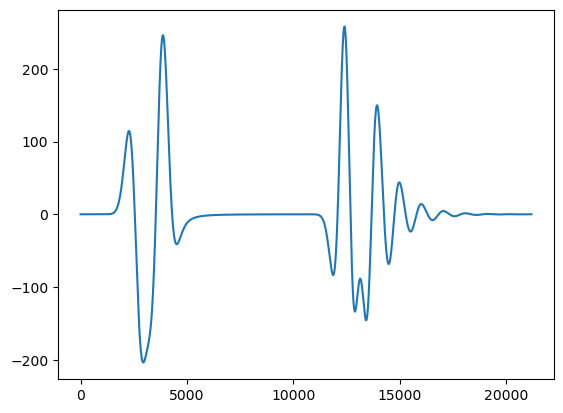

In [18]:
plt.plot(sim)

# 4. Making experimental and numerical signal the same size

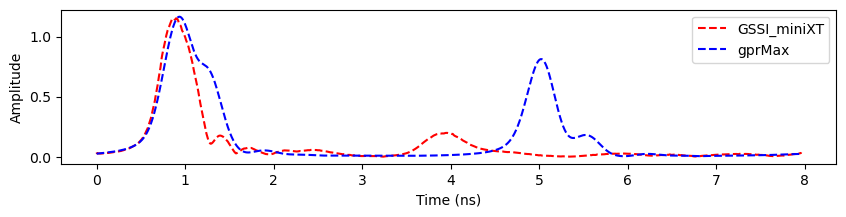

In [7]:
# Changing shape of the experimental signal
original_vector = -exp
new_size = sim.shape[0]  # Specify the desired new size
original_indices = np.arange(original_vector.size) # Create an array of indices for the original vector
new_indices = np.linspace(0, original_indices.max(), new_size) # Create an array of indices for the new vector
E_new = np.interp(new_indices, original_indices, original_vector) # Perform linear interpolation

E_new_normalized = E_new/(np.max(abs(E_new)));          # Normalize the experimental signals   
sim_normalized = sim/(np.max(abs(sim)))                 # Normalize the simulational signals   

E_new_normalized = np.abs(hilbert(E_new_normalized));   # Hilbert transform of experimental signal
sim_normalized = np.abs(hilbert(sim_normalized))        # Hilbert transform of simulational signal


# Plot comparison of experimental and numerical signal with RANDOM incorrect parameter values
df = 1/tw; 
fd = (E_new_normalized.shape[0]-1)*df;    
dt = 1/fd;  
t = np.arange(0,tw+dt,dt);  
t = t*1e9; 

plt.figure(figsize=(10, 2))
plt.plot(t,E_new_normalized,color='red',label='GSSI_miniXT', linestyle='--'); 
plt.plot(t,sim_normalized,color='blue',label='gprMax', linestyle='--'); 
plt.xlabel('Time (ns)'); 
plt.ylabel('Amplitude'); 
plt.legend(); 
plt.show();


# 5. Bayesian Optimization

In [8]:
# from bayes_opt import BayesianOptimization

# #-- Error Function:
# def mae_func(p1, c1, p2, c2, sd2):
#     vector1 = E_new_normalized;    
#     vector2 = model_2L(p1, c1, p2, c2, sd2)
#     vector2 = np.abs(hilbert(vector2/(np.max(abs(vector2)))))
#     rel_error = -100*np.sqrt(np.sum((vector1 - vector2)**2))/(np.sqrt(np.sum(vector1**2))) # Relative error (objective function)
#     return rel_error

# #-- Setting upper and lower bounds of each parameter:
# bounds = {'p1':(1,23), 
#           'c1':(0,0.15), 
#           'p2':(1,15), 
#           'c2':(0,0.03), 
#           'sd2':(0.02,0.2)};     

# #-- Initializing Bayesian Optimization:
# optimizer = BayesianOptimization(f=mae_func, 
#                                  pbounds=bounds, 
#                                  random_state=42)

# #-- Running Bayesian Optimization with initial points and iterations:
# # optimizer.maximize(init_points=550, n_iter=200)
# optimizer.maximize(init_points=100, n_iter=20)

# #-- Printing completion message and the best parameters found:
# print("Optimization completed successfully.");
# print(optimizer.max)

# 6. Bayesian Inference using MCMC

In [9]:
# from multiprocessing.pool import Pool
# import emcee
# import time
# import numpy as np
# import os
# # Import from the external file to support multiprocessing on Windows
# from forward_model import log_posterior

# t_total=[]; 
# t0 = time.time()


# # Setting bounds for parameter space
# bounds = {'p1': (1,23), 'c1': (0,0.1), 'p2': (1,9), 'c2': (0,0.1),  'sd2': (0.02, 0.18)}


# # Set the number of walkers and the number of steps for the MCMC sampler
# nwalkers = 20
# nsteps = 160
# ndim = 5


# # Set the initial positions of the walkers by sampling from the prior distribution
# p0 = np.random.uniform(low =[bounds['p1'][0], bounds['c1'][0], bounds['p2'][0], bounds['c2'][0], bounds['sd2'][0]], 
#                        high=[bounds['p1'][1], bounds['c1'][1], bounds['p2'][1], bounds['c2'][1], bounds['sd2'][1]], 
#                        size=(nwalkers, 5))


# if __name__ == "__main__":
#     # Configure the backend to save results to an HDF5 file
#     filename = "Bayesian_inversion.h5"
#     backend = emcee.backends.HDFBackend(filename)
#     backend.reset(nwalkers, ndim) # Clear the file if it exists
    
#     # Ensure E_new_normalized is available. It should have been calculated in previous cells.
#     # We pass it as an argument to the log_posterior function via emcee's args parameter.
    
#     with Pool() as pool:
#         # Initialize the MCMC sampler, Run the sampler and get the posterior samples
#         # args=[E_new_normalized] passes the data to the log_posterior function
#         sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, pool=pool, args=[E_new_normalized], backend=backend) 
#         pos, prob, state = sampler.run_mcmc(p0, nsteps, progress=True)             # Run the MCMC sampler
#         samples = sampler.flatchain                                 # Get the posterior samples


#         # Calculate the end time and print the time needed to complete
#         t1 = time.time(); 
#         t_total.append(t1 - t0); 
#         print('Time (hrs)=', np.array(t_total)/3600)

In [ ]:
from multiprocessing.pool import Pool
import emcee
import time
import numpy as np
import os
# Import from the external file to support multiprocessing on Windows
from forward_model import log_posterior

t_total=[]; 
t0 = time.time()


# Setting bounds for parameter space
bounds = {'p1': (1,23), 'c1': (0,0.1), 'p2': (1,9), 'c2': (0,0.1),  'sd2': (0.02, 0.18)}


# Set the number of walkers and the number of steps for the MCMC sampler
nwalkers = 20
nsteps = 3000   # Set target number of ADDITIONAL steps to run (e.g., 3000 for convergence)
ndim = 5


# Set the initial positions of the walkers by sampling from the prior distribution
p0 = np.random.uniform(low =[bounds['p1'][0], bounds['c1'][0], bounds['p2'][0], bounds['c2'][0], bounds['sd2'][0]], 
                       high=[bounds['p1'][1], bounds['c1'][1], bounds['p2'][1], bounds['c2'][1], bounds['sd2'][1]], 
                       size=(nwalkers, 5))


if __name__ == "__main__":
    # Configure the backend to save results to an HDF5 file
    filename = "Bayesian_inversion.h5"
    backend = emcee.backends.HDFBackend(filename)
    
    # --- RESUME OPTION ---
    resume = True  # Set to True to append to existing chain, False to restart
    
    if resume and os.path.exists(filename):
        print(f"Resuming run from {filename}...")
        print(f"Previous chain length: {backend.iteration}")
        initial_state = None  # Passing None tells emcee to resume from backend
    else:
        print(f"Starting fresh run in {filename}...")
        backend.reset(nwalkers, ndim) # Clear the file if it exists
        initial_state = p0
    # ---------------------
    
    # Ensure E_new_normalized is available. It should have been calculated in previous cells.
    # We pass it as an argument to the log_posterior function via emcee's args parameter.
    
    with Pool() as pool:
        # Initialize the MCMC sampler, Run the sampler and get the posterior samples
        # args=[E_new_normalized] passes the data to the log_posterior function
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, pool=pool, args=[E_new_normalized], backend=backend) 
        
        # run_mcmc will run for 'nsteps' iterations. 
        # If resuming, these are appended to the existing chain.
        pos, prob, state = sampler.run_mcmc(initial_state, nsteps, progress=True)             
        samples = sampler.flatchain                                 # Get the posterior samples


        # Calculate the end time and print the time needed to complete
        t1 = time.time(); 
        t_total.append(t1 - t0); 
        print('Time (hrs)=', np.array(t_total)/3600)
        print(f"Total steps stored: {backend.iteration}")

Resuming run from Bayesian_inversion.h5...
Previous chain length: 1


  6%|▋         | 195/3000 [1:26:54<18:01:12, 23.13s/it]

In [ ]:
from multiprocessing import cpu_count

ncpu = cpu_count()
print("{0} CPUs".format(ncpu))

16 CPUs


## 6a. Plot the posterior distributions of the parameters


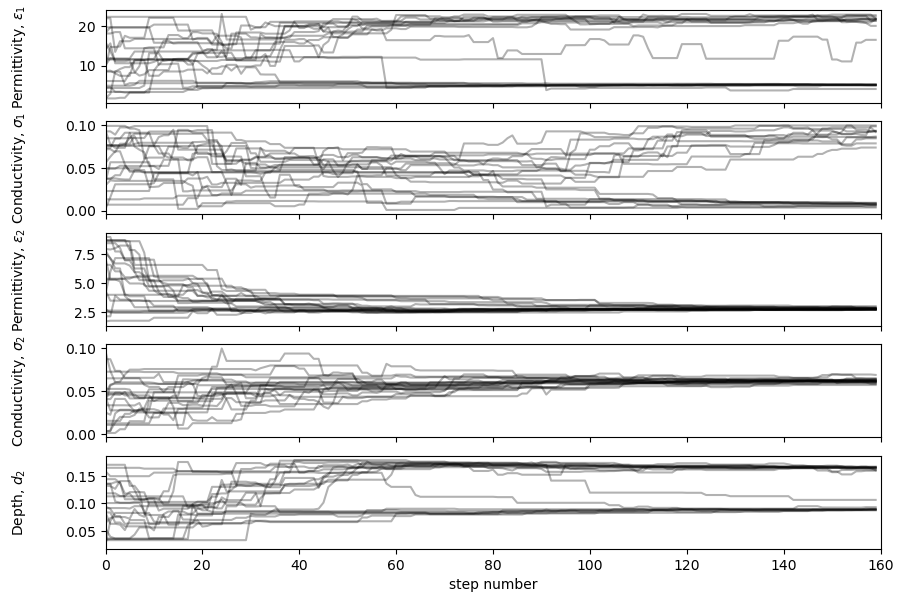

In [ ]:
ndim = 5

fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels=[r"Permittivity, $\varepsilon_1$", r"Conductivity, $σ_1$", r"Permittivity, $\varepsilon_2$", r"Conductivity, $σ_2$", r"Depth, $d_2$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 3;
tau: [17.98478195 17.58966079 16.82882663 18.54081355 17.44999546]

In [ ]:
flat_chain = sampler.get_chain(flat=True) # Get the flat chain with shape (nwalkers * nsteps, ndim)

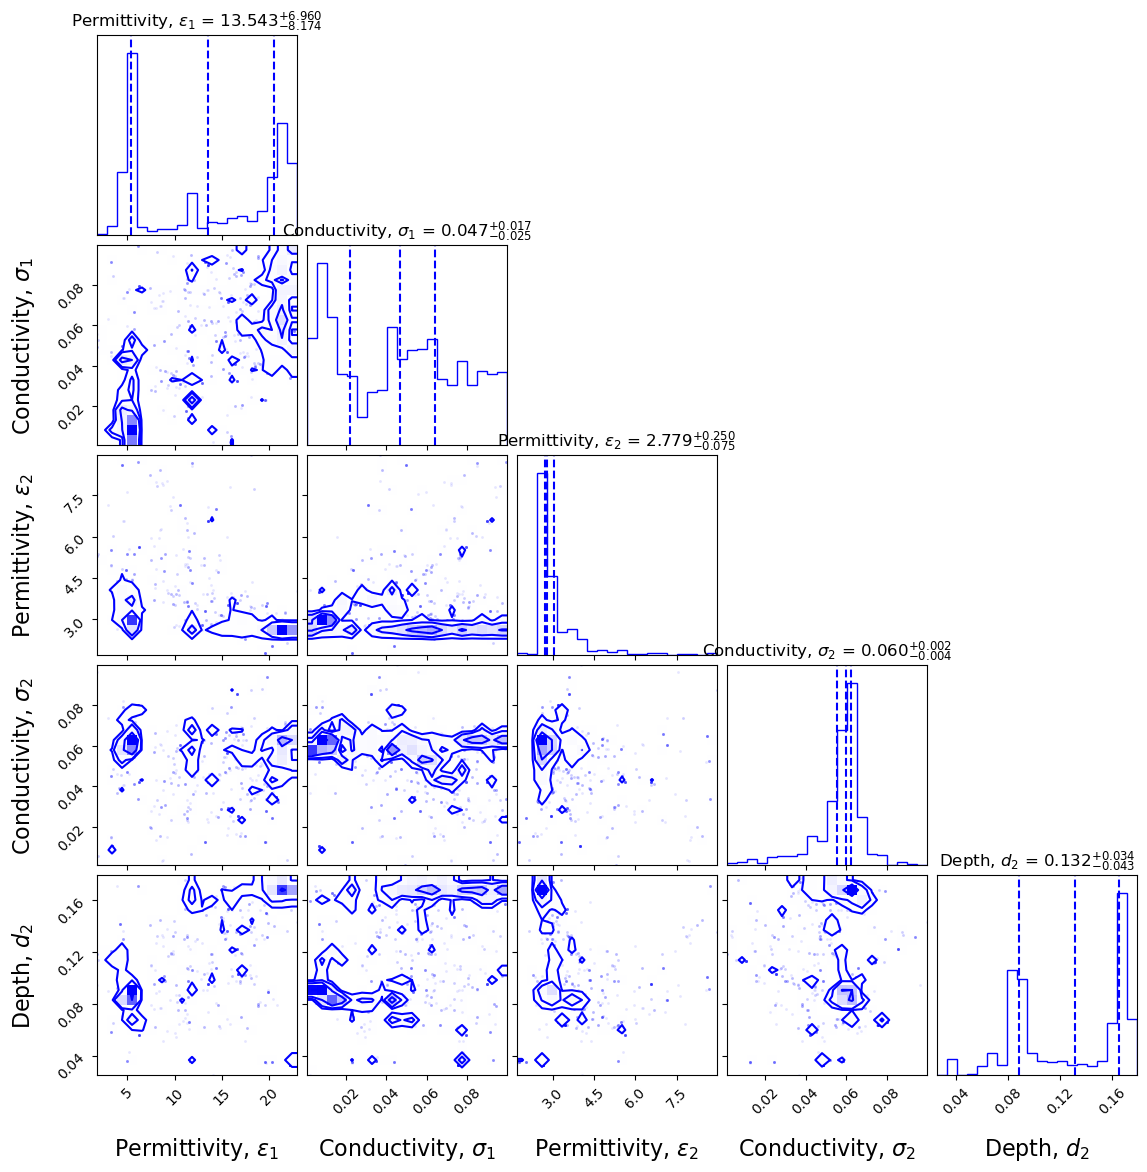

In [ ]:
import corner
label_props = {'fontsize': 16}

fig = corner.corner(flat_chain, 
                    quantiles=[.30, .50, .70], 
                    labels=[r"Permittivity, $\varepsilon_1$", r"Conductivity, $σ_1$", r"Permittivity, $\varepsilon_2$", r"Conductivity, $σ_2$", r"Depth, $d_2$"], 
                    color='b', show_titles=True, title_fmt='.3f', label_kwargs=label_props, hist_bin_factor = 1)

# 7. Compare experimental and numerical signal with predicted parameters

| ID | GPU | MEM |
------------------
|  0 |  3% | 18% |


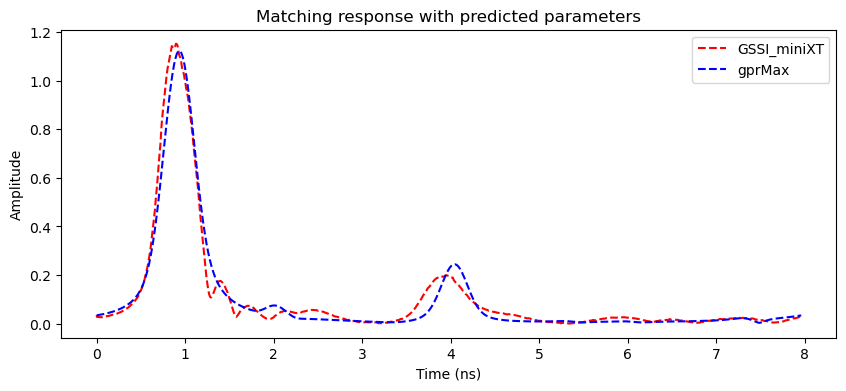

np.float64(16.405640683558065)

In [ ]:
# Run simulation with predicted parameter values
sim = model_2L(p1=4.1, c1=.03, p2=3.47, c2=.014, sd2= 0.109)

# Changing shape of the experimental signal
original_vector = -exp
new_size = sim.shape[0]  # Specify the desired new size
original_indices = np.arange(original_vector.size) # Create an array of indices for the original vector
new_indices = np.linspace(0, original_indices.max(), new_size) # Create an array of indices for the new vector
E_new = np.interp(new_indices, original_indices, original_vector) # Perform linear interpolation

E_new_normalized = E_new/(np.max(abs(E_new)));          # Normalize the experimental signals   
sim_normalized = sim/(np.max(abs(sim)))                 # Normalize the simulational signals   

E_new_normalized = np.abs(hilbert(E_new_normalized));   # Hilbert transform of experimental signal
sim_normalized = np.abs(hilbert(sim_normalized))        # Hilbert transform of simulational signal


# Plot the two results
df = 1/tw; 
fd = (E_new_normalized.shape[0]-1)*df;    
dt = 1/fd;  
t = np.arange(0,tw+dt,dt);  
t = t*1e9; 

plt.figure(figsize=(10, 4))
plt.plot(t,E_new_normalized,color='red',label='GSSI_miniXT', linestyle='--'); 
plt.plot(t,sim_normalized,color='blue',label='gprMax', linestyle='--'); 
plt.xlabel('Time (ns)'); 
plt.ylabel('Amplitude'); 
plt.title('Matching response with predicted parameters')
plt.legend(); 
plt.show();

100*np.sqrt(np.sum((E_new_normalized - sim_normalized)**2))/(np.sqrt(np.sum(E_new_normalized**2)))
